# 工具使用（函数调用）

## 工具使用模式概述

到目前为止，我们讨论了以协调语言模型之间交互及管理信息流为主的智能体模式（如链式、路由、并行化、反思等）。然而，要让智能体真正有用并能与现实世界或外部系统（工具）交互，必须具备使用工具的能力。

工具使用模式通常通过“函数调用”机制实现，使智能体能够与外部API、数据库、服务或执行代码交互。LLM（大型语言模型）作为核心，决定何时以及如何基于用户请求或当前任务状态调用特定外部函数。

### 过程步骤包括：
1. **工具定义**：定义外部函数或能力，包括函数目的、名称、参数及描述。
2. **LLM决策**：LLM接收用户请求和工具定义，判断是否需要调用一个或多个工具。
3. **函数调用生成**：若LLM决定使用工具，会生成结构化输出（通常为JSON），指定调用哪个工具和参数。
4. **工具执行**：框架或编排层拦截该输出，执行实际外部函数且传入参数。
5. **观察结果**：返回工具执行的结果给智能体。
6. **LLM处理（可选但常见）**：LLM用工具输出作为上下文，生成最终回复或决定后续动作。

该模式突破了LLM训练数据的限制，使其能访问最新信息、执行计算和触发实际操作。

函数调用技术桥接了LLM推理能力与丰富外部功能之间的差距。

“函数调用”不仅指调用预定义代码函数，还包括调用复杂API端点、数据库请求或指令给其他智能体，支持更丰富的协同与自动化。

像LangChain、LangGraph和Google Agent Developer Kit（ADK）等框架，提供工具定义和集成支持，让智能体能意识并使用这些工具。

工具使用模式是构建强大、交互性强、具备外部感知能力智能体的基石。

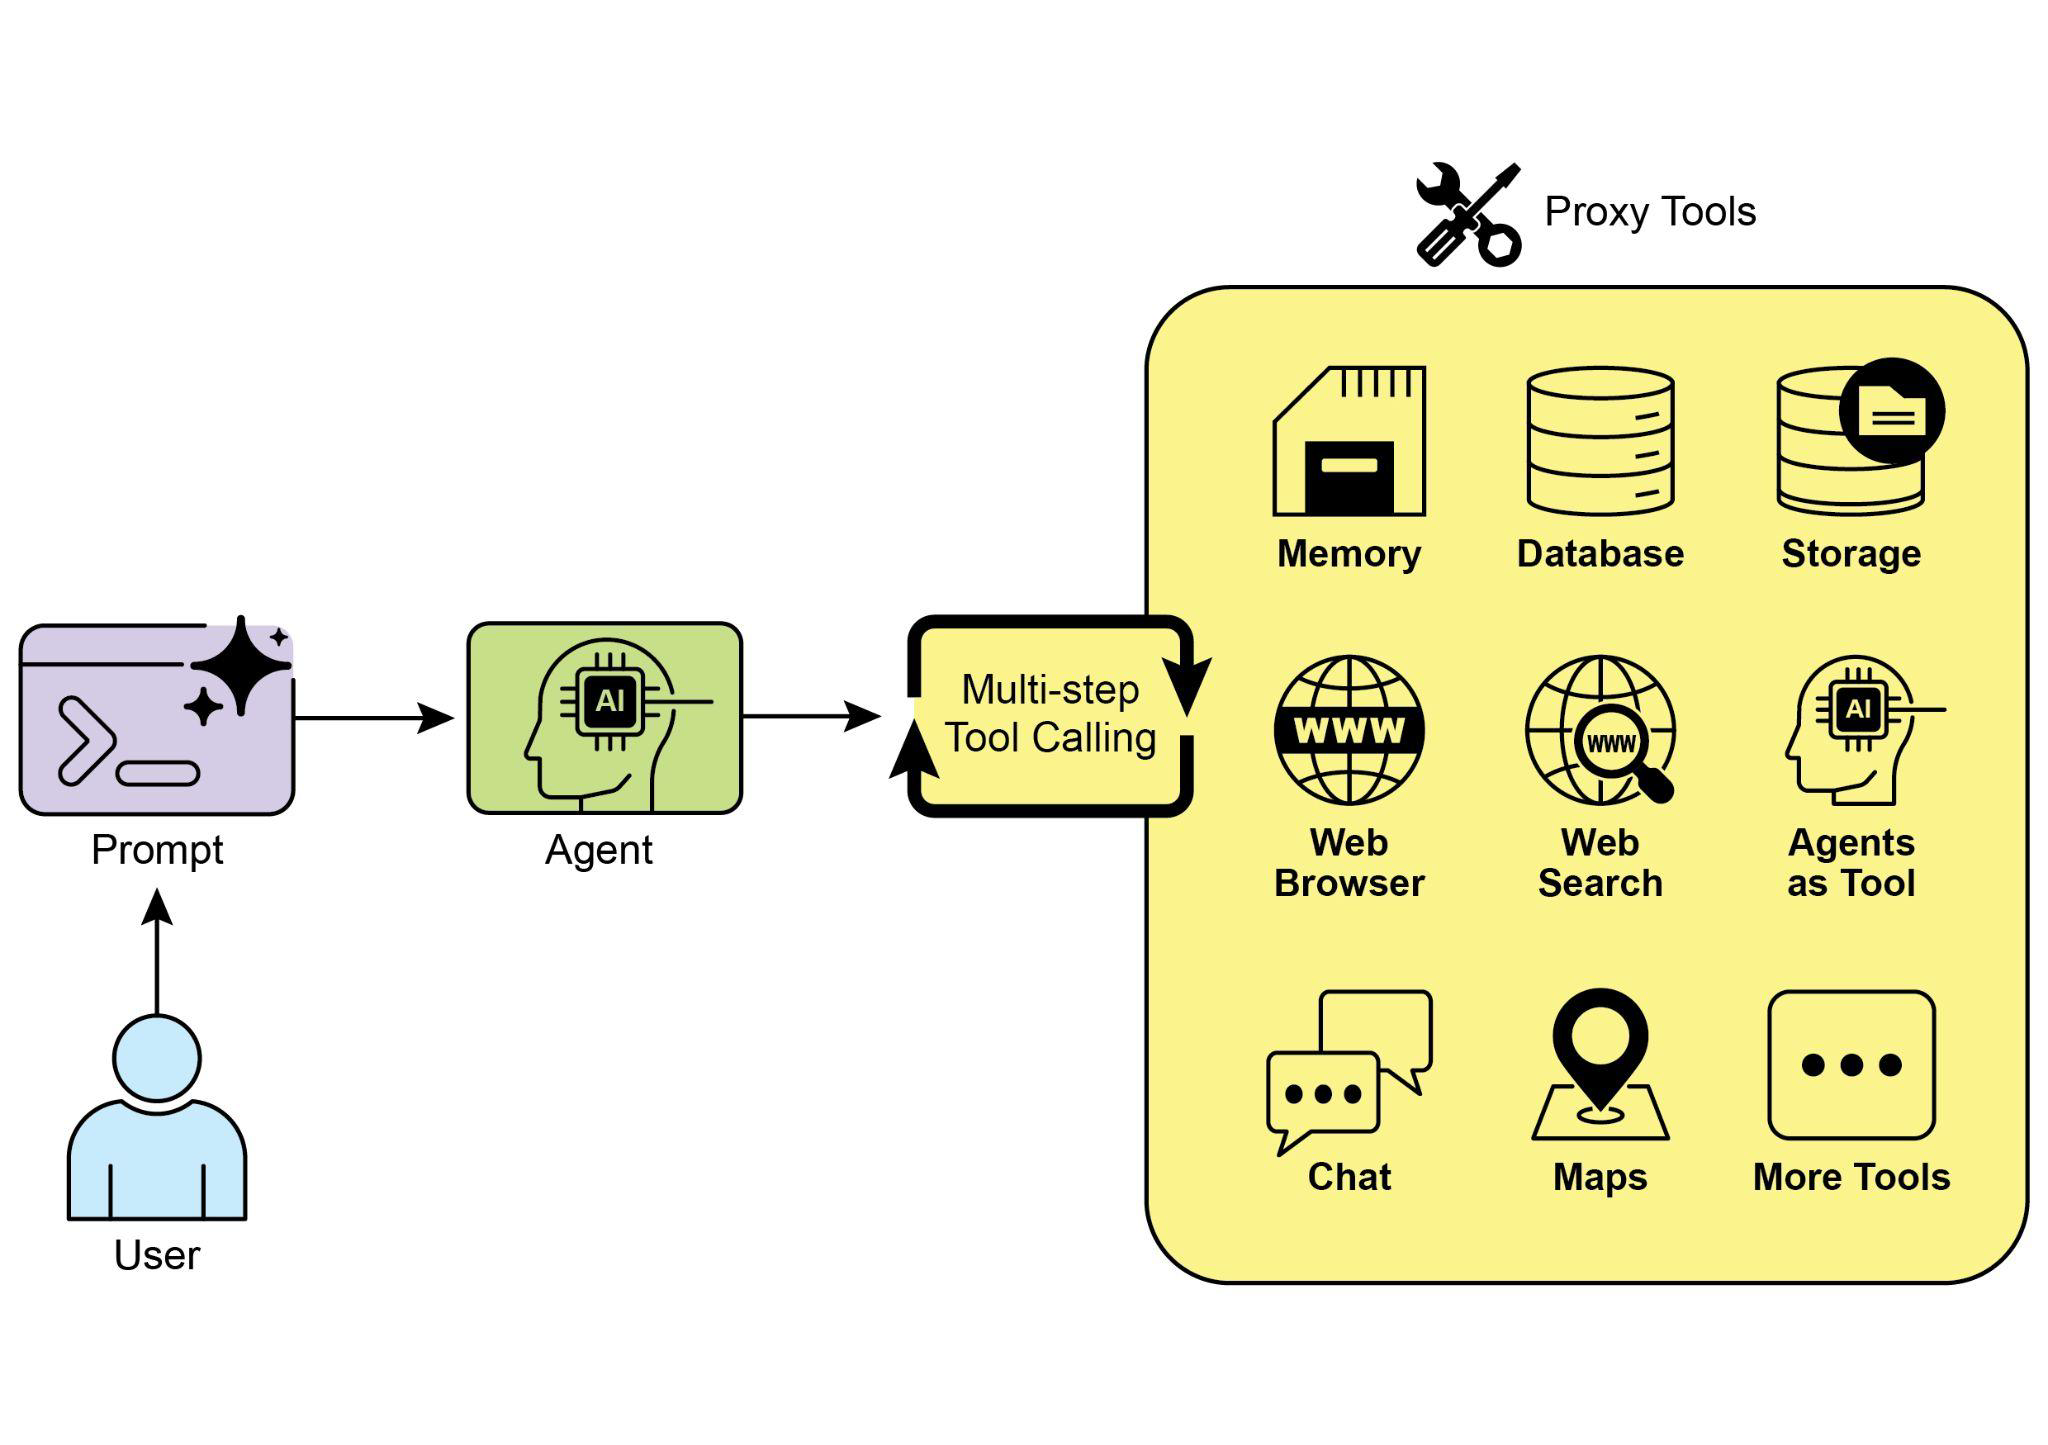

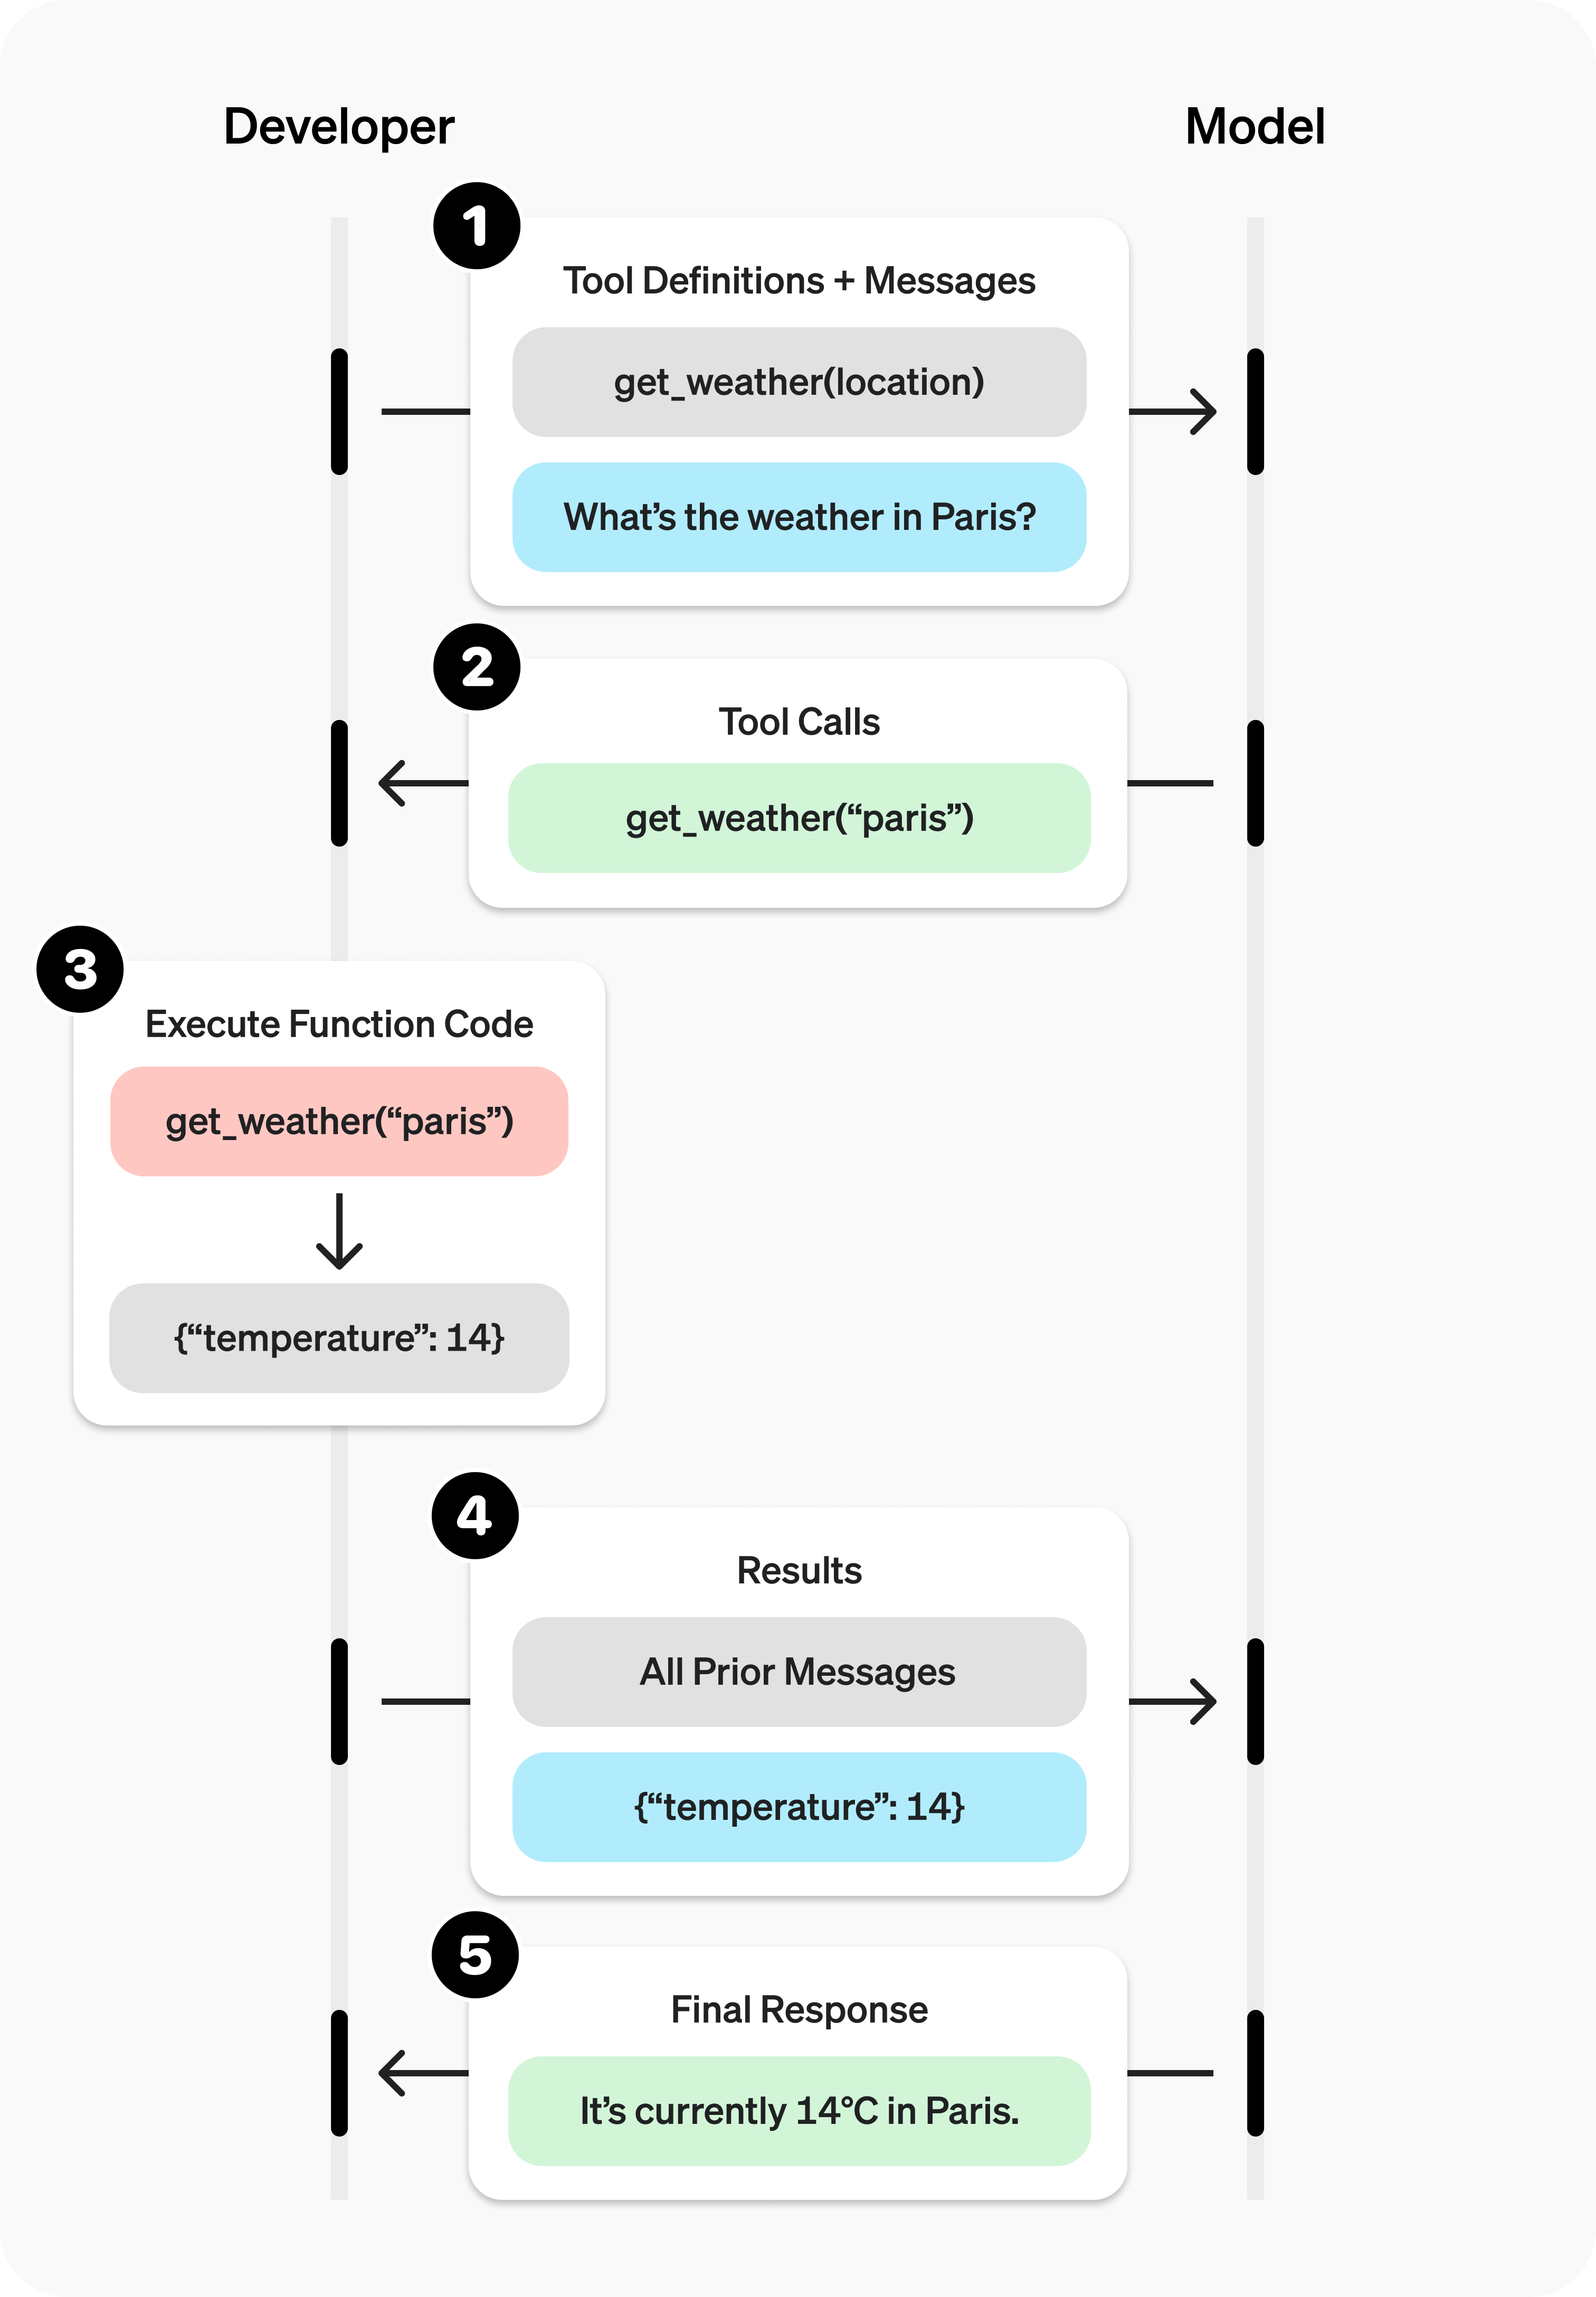

## 实际应用与使用案例

工具使用模式几乎适用于任何需要代理执行操作或检索特定动态信息的场景，超越仅生成文本的能力：

1. **从外部来源检索信息：**
   访问实时数据或大型语言模型（LLM）训练数据中不存在的信息。
   - **使用案例：** 天气代理。
   - **工具：** 天气API，根据地点返回当前天气。
   - **代理流程：** 用户询问“伦敦的天气如何？”，LLM识别需要调用天气工具，用“London”作为参数调用API，返回数据后格式化为用户友好回答。

2. **与数据库和API交互：**
   执行查询、更新或其他结构化数据操作。
   - **使用案例：** 电子商务代理。
   - **工具：** 通过API检查库存、订单状态或处理支付。
   - **代理流程：** 用户问“产品X有库存吗？”，LLM调用库存API，返回库存状态并告知用户。

3. **执行计算与数据分析：**
   使用外部计算器、数据分析库或统计工具。
   - **使用案例：** 财务代理。
   - **工具：** 计算器函数、股票市场数据API、电子表格工具。
   - **代理流程：** 用户问“当前AAPL股票价格及购买100股后潜在利润？”，LLM调用股票API和计算器工具，得到结果并格式化回复。

4. **发送通信：**
   发送邮件、消息，或调用外部通信服务API。
   - **使用案例：** 个人助理代理。
   - **工具：** 邮件发送API。
   - **代理流程：** 用户说“发送邮件给John，关于明天会议”，LLM调用邮件工具，提取收件人、主题和正文，然后发送。

5. **执行代码：**
   在安全环境中运行代码片段以执行特定任务。
   - **使用案例：** 编程助理代理。
   - **工具：** 代码解释器。
   - **代理流程：** 用户提供Python代码并问“代码功能是什么？”，LLM运行代码解释器，分析输出并回复。

6. **控制其他系统或设备：**
   与智能家居设备、物联网平台或其他连接系统交互。
   - **使用案例：** 智能家居代理。
   - **工具：** 控制智能灯光的API。
   - **代理流程：** 用户说“关闭客厅灯”，LLM调用智能家居工具执行命令。

**总结：**
工具使用使语言模型从文本生成器转变为能够感知、推理并在数字或物理世界中执行行为的智能代理。

## 实战代码：使用 LangChain
该代码使用LangChain库和Google Gemini模型设置了一个工具调用代理。具体功能如下：

- 定义了一个`search_information`工具，模拟对特定查询提供事实性回答。
- 该工具对以下查询有预定义回答：
  - "weather in london"
  - "capital of france"
  - "population of earth"
- 对其他查询提供默认回应。
- 初始化了一个ChatGoogleGenerativeAI模型，确保具备工具调用功能。
- 创建了一个ChatPromptTemplate，引导代理的交互。
- 使用`create_tool_calling_agent`函数将语言模型、工具和提示组合成代理。
- 使用AgentExecutor管理代理的执行和工具调用。
- 定义了异步函数`run_agent_with_tool`，向代理传入查询并打印结果。
- 该异步主函数同时执行多个查询，以测试工具对具体和默认回答的处理。
- 代码包含了在代理初始化成功后才执行任务的检查。

总体来说，该代码展示了如何结合语言模型与工具调用，创建一个能针对多种查询返回预定义或默认回应的智能代理。

In [1]:
import dotenv
dotenv.load_dotenv()

True

In [1]:
import os, getpass
import asyncio
import nest_asyncio
from typing import List
from dotenv import load_dotenv
import logging
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool as langchain_tool
from langchain.agents import create_agent

In [2]:
try:
   # A model with function/tool calling capabilities is required.
   # 需要一个具有函数调用能力的模型，这里使用 Gemini 2.0 Flash。
   llm = ChatOpenAI(base_url="http://127.0.0.1:1234/v1", temperature=0, api_key="not-needed")
   #print(f"✅ Language model initialized: {llm.model}")
except Exception as e:
   #print(f"🛑 Error initializing language model: {e}")
   llm = None

In [3]:
# --- Define a Tool ---
# --- 定义模拟的搜索工具 ---
@langchain_tool
def search_information(query: str) -> str:
   """
   Provides factual information on a given topic. Use this tool to find answers to phrases
   like 'capital of France' or 'weather in London?'.
   # 模拟提供关于特定查询的输出。使用此工具查找类似「法国的首都是哪里？」或「伦敦的天气如何？」这类问题的答案。
   """
   print(f"\n--- 🛠️ Tool Called: search_information with query: '{query}' ---")
   # Simulate a search tool with a dictionary of predefined results.
   # 通过一个字典预定义的结果来模拟搜索工具。
   simulated_results = {
       "weather in london": "The weather in London is currently cloudy with a temperature of 15°C.",
       "capital of france": "The capital of France is Paris.",
       "population of earth": "The estimated population of Earth is around 8 billion people.",
       "tallest mountain": "Mount Everest is the tallest mountain above sea level.",
       "default": f"Simulated search result for '{query}': No specific information found, but the topic seems interesting."
   }
   result = simulated_results.get(query.lower(), simulated_results["default"])
   print(f"--- TOOL RESULT: {result} ---")
   return result

tools = [search_information]

In [ ]:
# --- Create a Tool-Calling Agent ---
# --- 创建一个使用工具的智能体 ---
if llm:
   # This prompt template requires an `agent_scratchpad` placeholder for the agent's internal steps.
   # 这个提示模板需要一个 `agent_scratchpad` 占位符，用于记录智能体的内部步骤。
   agent_prompt = ChatPromptTemplate.from_messages([
       ("system", "You are a helpful assistant."),
       ("human", "{input}"),
       ("placeholder", "{agent_scratchpad}"),
   ])

   # Create the agent, binding the LLM, tools, and prompt together.
   # 使用定义好的大语言模型、工具和提示词模板构建智能体。
   agent_executor = create_agent(llm, tools=tools)



In [ ]:

async def run_agent_with_tool(query: str):
   """
   Invokes the agent executor with a query and prints the final response.
   执行智能体并打印最终输出信息。
   """
   print(f"\n--- 🏃 Running Agent with Query: '{query}' ---")
   try:
       response = await agent_executor.ainvoke({"input": query})
       print("\n--- ✅ Final Agent Response ---")
       print(response["output"])
   except Exception as e:
       print(f"\n🛑 An error occurred during agent execution: {e}") 

In [20]:
async def main():
   """
   Runs all agent queries concurrently.
   并发运行所有智能体查询任务。
   """
   tasks = [
       run_agent_with_tool("What is the capital of France?"),
       run_agent_with_tool("What's the weather like in London?"),
       run_agent_with_tool("Tell me something about dogs.") # Should trigger the default tool response
   ]
   await asyncio.gather(*tasks)

await main()


--- 🏃 Running Agent with Query: 'What is the capital of France?' ---

--- 🏃 Running Agent with Query: 'What's the weather like in London?' ---

--- 🏃 Running Agent with Query: 'Tell me something about dogs.' ---

--- 🛠️ Tool Called: search_information with query: 'weather in London today' ---
--- TOOL RESULT: Simulated search result for 'weather in London today': No specific information found, but the topic seems interesting. ---

--- ✅ Final Agent Response ---
The capital of France is Paris. It is located in the north-central part of the country and serves as the nation's political, economic, and cultural center.

--- ✅ Final Agent Response ---


--- ✅ Final Agent Response ---
Dogs are fascinating creatures that have been humanity's most loyal companions for thousands of years! Here are a few interesting things to know:

*   **Ancient Origins**: Dogs were the first species to be domesticated by humans, likely around 15,000 to 30,000 years ago. They evolved from wolves.
*   **Super Se

## 使用 CrewAI

- 代码演示了使用 Crew.ai 库模拟金融分析任务的简单应用。
- 定义了一个自定义工具 `get_stock_price`，用于模拟查询预定义股票代码的股票价格。
- 工具返回有效股票代码的浮点数价格，无效股票代码则抛出 `ValueError`。
- 创建了一个名为 `financial_analyst_agent` 的 Crew.ai 代理，角色为高级金融分析师。
- 将 `get_stock_price` 工具分配给该代理以便交互使用。
- 定义了任务 `analyze_aapl_task`，指示代理使用工具查找 AAPL 的模拟股价。
- 任务描述中包含成功和失败情况的处理指令。
- 组建了一个 Crew，包含金融分析师代理和任务。
- 代理和 Crew 的 `verbose` 设置为开启，提供详细的执行日志。
- 主程序通过 `if __name__ == "__main__"` 结构运行 Crew 的任务，使用 `kickoff()` 方法启动。
- 启动前检查 `OPENAI_API_KEY` 环境变量是否设置，确保代理能正常工作。
- 打印 Crew 执行的结果，即任务的输出。
- 配置了基本日志记录，便于追踪 Crew 的动作和工具调用。
- 使用环境变量管理 API 密钥，生产环境建议使用更安全的方法。
- 总结来说，代码展示了如何定义工具、代理和任务，进而在 Crew.ai 中创建协同工作流程。

In [16]:
import os
from crewai import Agent, Task, Crew, LLM
from crewai.tools import tool
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [ ]:
llm = LLM(model='lm_studio/qwen3.5-opus_9b', base_url="http://127.0.0.1:1234/v1", api_key="not-needed")

In [24]:
# --- 1. 重构后的工具 ---
# 该工具现在返回模拟的股价（一个浮点数）或抛出标准的 Python 错误。
# 这样可以提高可重用性，并确保智能体在处理结果时采取适当的处理措施
@tool("Stock Price Lookup Tool")
def get_stock_price(ticker: str) -> float:
    """
    Fetches the latest simulated stock price for a given stock ticker symbol.
    Returns the price as a float. Raises a ValueError if the ticker is not found.
    获取指定股票代码的最新模拟股价信息。
    返回该股票的价格（浮点数）。如果找不到该代码，会抛出 ValueError 异常。
    """
    logging.info(f"Tool Call: get_stock_price for ticker '{ticker}'")
    simulated_prices = {
        "AAPL": 178.15,
        "GOOGL": 1750.30,
        "MSFT": 425.50,
    }
    price = simulated_prices.get(ticker.upper())

    if price is not None:
        return price
    else:
        # Raising a specific error is better than returning a string.
        # The agent is equipped to handle exceptions and can decide on the next action.
        # 与其返回一个字符串，不如抛出一个明确的错误，这样更清晰也便于处理。
        # 该智能体具备异常处理能力，能够在发生问题时判断并选择合适的后续动作。
        raise ValueError(f"Simulated price for ticker '{ticker.upper()}' not found.")

In [ ]:
# 智能体的定义仍然沿用原有内容，不过现在会使用增强后的工具
financial_analyst_agent = Agent(
  llm=llm,
  role='Senior Financial Analyst',
  goal='Analyze stock data using provided tools and report key prices.',
  backstory="You are an experienced financial analyst adept at using data sources to find stock information. You provide clear, direct answers.",
  verbose=True,
  tools=[get_stock_price],
  # Allowing delegation can be useful, but is not necessary for this simple task.
  # 允许委托在某些情况下很有用，但对于这个简单的任务并非必需。
  allow_delegation=False,
)

In [26]:
# 任务描述更加详尽，能够指导智能体在查询成功和抛出错误时都采取正确的处理。
analyze_aapl_task = Task(
  description=(
      "What is the current simulated stock price for Apple (ticker: AAPL)? "
      "Use the 'Stock Price Lookup Tool' to find it. "
      "If the ticker is not found, you must report that you were unable to retrieve the price."
  ),
  expected_output=(
      "A single, clear sentence stating the simulated stock price for AAPL. "
      "For example: 'The simulated stock price for AAPL is $178.15.' "
      "If the price cannot be found, state that clearly."
  ),
  agent=financial_analyst_agent,
)

In [27]:
# 由该实例来负责协调智能体和任务
financial_crew = Crew(
  agents=[financial_analyst_agent],
  tasks=[analyze_aapl_task],
  verbose=True # Set to False for less detailed logs in production
)

In [28]:
# The kickoff method starts the execution.
# 使用 kickoff 方法启动执行。
result = financial_crew.kickoff()

print("\n---------------------------------")
print("## Crew execution finished.")
print("\nFinal Result:\n", result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 1a8680ae-ac60-4a2e-ab5d-5023c58c5ac9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: What is the current simulated stock price for Apple (ticker: AAPL)? Use the 'Stock Price Lookup Tool'    │
│  to find it. If the ticker is not found, you must report that you were unable to retrieve the price.            │
│  ID: 01daf3bd-113d-4b40-b0ea-2df303eb2c5f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

11:14:53 - LiteLLM:INFO: utils.py:3748 - 
LiteLLM completion() model= qwen3.5-opus_9b; provider = lm_studio


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Financial Analyst                                                                                │
│                                                                                                                 │
│  Task: What is the current simulated stock price for Apple (ticker: AAPL)? Use the 'Stock Price Lookup Tool'    │
│  to find it. If the ticker is not found, you must report that you were unable to retrieve the price.            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

2026-03-20 11:14:53,648 - INFO - 
LiteLLM completion() model= qwen3.5-opus_9b; provider = lm_studio


...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Financial Analyst                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The simulated stock price for AAPL is $178.15.                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: What is the current simulated stock price for Apple (ticker: AAPL)? Use the 'Stock Price Lookup Tool'    │
│  to find it. If the ticker is not found, you must report that you were unable to retrieve the price.            │
│  Agent: Senior Financial Analyst                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 1a8680ae-ac60-4a2e-ab5d-5023c58c5ac9                                                                       │
│  Final Output: The simulated stock price for AAPL is $178.15.                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


---------------------------------
## Crew execution finished.

Final Result:
 The simulated stock price for AAPL is $178.15.


╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 使用Datasurfer

In [30]:
import datasurfer as ds
from datasurfer.lib_llm.utility import agent_tool

In [32]:
@agent_tool
def get_stock_price(ticker: str) -> float:
    """
    Fetches the latest simulated stock price for a given stock ticker symbol.
    Returns the price as a float. Raises a ValueError if the ticker is not found.
    获取指定股票代码的最新模拟股价信息。
    返回该股票的价格（浮点数）。如果找不到该代码，会抛出 ValueError 异常。
    """
    logging.info(f"Tool Call: get_stock_price for ticker '{ticker}'")
    simulated_prices = {
        "AAPL": 178.15,
        "GOOGL": 1750.30,
        "MSFT": 425.50,
    }
    price = simulated_prices.get(ticker.upper())

    if price is not None:
        return price
    else:
        # Raising a specific error is better than returning a string.
        # The agent is equipped to handle exceptions and can decide on the next action.
        # 与其返回一个字符串，不如抛出一个明确的错误，这样更清晰也便于处理。
        # 该智能体具备异常处理能力，能够在发生问题时判断并选择合适的后续动作。
        raise ValueError(f"Simulated price for ticker '{ticker.upper()}' not found.")

In [33]:
agent = ds.Agent(
  'LA',
  name='Senior Financial Analyst',
  description='Analyze stock data using provided tools and report key prices.',
  instructions="You are an experienced financial analyst adept at using data sources to find stock information. You provide clear, direct answers.",
  tools=[get_stock_price],
)

In [34]:
# 任务描述更加详尽，能够指导智能体在查询成功和抛出错误时都采取正确的处理。
query = (
      "What is the current simulated stock price for Apple (ticker: AAPL)? "
      "Use the 'Stock Price Lookup Tool' to find it. "
      "If the ticker is not found, you must report that you were unable to retrieve the price."
    
      "The Output should be a single, clear sentence stating the simulated stock price for AAPL. "
      "For example: 'The simulated stock price for AAPL is $178.15.' "
      "If the price cannot be found, state that clearly."
  )

agent.resp(query)


2026-03-20 13:27:53,239 - INFO - Tool Call: get_stock_price for ticker 'AAPL'


Senior financial analyst:

    Reasoning:
    Let me analyze this request carefully.

    The user is asking for the current simulated stock price for Apple (AAPL). Looking at the
    available tools:

    1. `get_stock_price` - This tool fetches the latest simulated stock price for a given stock
    ticker symbol. It requires just one parameter: `ticker`.

    This appears to be a straightforward request that doesn't require any special skill instructions
    or reference materials. The task is simply to retrieve and report the stock price using the
    provided tool.

    I should call the get_stock_price function with "AAPL" as the ticker parameter.

    Function Call:
        Name: get_stock_price
        Arguments: {"ticker":"AAPL"}
        Call ID: call_367728481560005


--------------------------------------------------------------------------------------------------------

Senior financial analyst:

    Reasoning:
    Let me analyze this request:

    1. The user wants to know 

'The simulated stock price for AAPL is $178.15.'

## 使用 Google ADK

该代码演示了如何创建和使用基于Google ADK for Python的基础代理。代理通过利用Google搜索作为工具来回答问题。

- 首先，导入IPython、google.adk和google.genai等必要库。
- 定义应用程序名称、用户ID和会话ID等常量。
- 创建一个名为“basic_search_agent”的Agent实例，带有描述和用途说明。
- 配置代理使用Google搜索工具，这是ADK提供的预构建工具。
- 初始化InMemorySessionService来管理会话。
- 创建新会话，关联应用程序、用户和会话ID。
- 实例化Runner，将代理与会话服务连接，用于执行代理在会话中的交互。
- 定义辅助函数call_agent，简化发送查询和处理响应流程。
- 在call_agent中，将用户查询格式化为types.Content对象，调用runner.run方法执行。
- runner.run返回事件列表，遍历事件找到最终响应文本并打印到控制台。
- 最后调用call_agent并传入查询“what's the latest ai news?”，演示代理的实际运行。

此代码体现了通过Google ADK构建和运行智能问答代理的基本步骤和流程。

In [27]:
from google.adk.agents import Agent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search
from google.genai import types
import nest_asyncio
import asyncio

In [28]:
APP_NAME="Google Search_agent"
USER_ID="user1234"
SESSION_ID="1234"

In [29]:
# Define Agent with access to search tool
# 定义一个可以使用搜索功能的智能体
root_agent = Agent(
   name="basic_search_agent",
   model="gemini-2.5-flash",
   description="Agent to answer questions using Google Search.",
   instruction="I can answer your questions by searching the internet. Just ask me anything!",
   tools=[google_search] # Google Search is a pre-built tool to perform Google searches. Google Search 是一个内置的工具，用来执行 Google 搜索。
)

In [30]:
# Agent Interaction
# 智能体调用函数
async def call_agent(query):
   """
   Helper function to call the agent with a query.
   辅助函数，传入查询参数调用智能体。
   """

   # Session and Runner
   # 会话和执行器
   session_service = InMemorySessionService()
   session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
   runner = Runner(agent=root_agent, app_name=APP_NAME, session_service=session_service)

   content = types.Content(role='user', parts=[types.Part(text=query)])
   events = runner.run(user_id=USER_ID, session_id=SESSION_ID, new_message=content)


   for event in events:
       if event.is_final_response():
           final_response = event.content.parts[0].text
           print("Agent Response: ", final_response)

nest_asyncio.apply()
asyncio.run(call_agent("what's the latest ai news?"))

Agent Response:  Here's a roundup of the latest artificial intelligence (AI) news from March 2026:

**Major Model Releases & Updates:**

*   **Google's Gemini 3.1 Pro** has demonstrated significant advancements, reportedly doubling previous performance on the ARC-AGI-2 benchmark and dominating 13 out of 16 major benchmarks.
*   **Anthropic** introduced **Claude Opus 4.6** with "adaptive thinking" capabilities, allowing the model to determine when deeper reasoning is required without user configuration. They also released Claude Sonnet 4.6 and introduced "Claude Import Memory" to facilitate transferring context from other AI assistants.
*   **OpenAI** launched **GPT-5.3 "Garlic"**, which focuses on cognitive density for improved knowledge per byte, and **GPT-5.3 Codex**, designed for complex programming tasks. OpenAI also updated GPT-5.3 Instant to refine its tone and reduce overly reassuring responses.
*   **xAI's Grok 4.20** introduced a unique four-agent architecture.
*   **MiniMax**

Google ADK 功能集成了用于专门任务的组件，包括动态代码执行的环境。
built_in_code_execution 工具为代理提供了一个沙箱环境的 Python 解释器。
这使模型能够编写并运行代码，以执行计算任务、操作数据结构和运行过程脚本。
这种功能对于解决需要确定性逻辑和精确计算的问题非常关键，而这些问题超出了概率语言生成的范围。


该脚本使用Google的Agent开发工具包（ADK）创建了一个通过编写和执行Python代码来解决数学问题的智能代理。它定义了一个LlmAgent，专门被指示充当计算器，配备了built_in_code_execution工具。主要逻辑在call_agent_async函数中，该函数将用户的查询发送给代理的运行器，并处理产生的事件。在此函数内部，有一个异步循环遍历事件，打印生成的Python代码及其执行结果以供调试。代码细致地区分了中间步骤和包含最终数值答案的事件。最后，主函数运行代理，使用两个不同的数学表达式来展示其计算能力

In [31]:
import os, getpass
import asyncio
import nest_asyncio
from typing import List
from dotenv import load_dotenv
import logging
from google.adk.agents import Agent as ADKAgent, LlmAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search
from google.adk.code_executors import BuiltInCodeExecutor
from google.genai import types

In [32]:
# Define variables required for Session setup and Agent execution
# 定义会话和智能体执行所需的变量
APP_NAME="calculator"
USER_ID="user1234"
SESSION_ID="session_code_exec_async"


# Agent Definition
# 定义一个可以执行代码的智能体
code_agent = LlmAgent(
   name="calculator_agent",
   model="gemini-2.0-flash",
   code_executor=BuiltInCodeExecutor(),
   instruction="""You are a calculator agent.
   When given a mathematical expression, write and execute Python code to calculate the result.
   Return only the final numerical result as plain text, without markdown or code blocks.
   """,
   description="Executes Python code to perform calculations.",
)


In [33]:
# Agent Interaction (Async)
# 异步执行智能体
async def call_agent_async(query):

   # Session and Runner
   # 创建会话和执行器
   session_service = InMemorySessionService()
   session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
   runner = Runner(agent=code_agent, app_name=APP_NAME, session_service=session_service)

   content = types.Content(role='user', parts=[types.Part(text=query)])
   print(f"\n--- Running Query: {query} ---")
   final_response_text = "No final text response captured."
   try:
       # Use run_async
       # 使用 run_async 方法异步执行智能体
       async for event in runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content):
           print(f"Event ID: {event.id}, Author: {event.author}")

           # --- Check for specific parts FIRST ---
           # has_specific_part = False
           # 首先检查是否有特定的部分
           if event.content and event.content.parts and event.is_final_response():
               for part in event.content.parts: # Iterate through all parts
                   if part.executable_code:
                       # Access the actual code string via .code
                       # 通过 .code 获取智能体生成的代码
                       print(f"  Debug: Agent generated code:\n```python\n{part.executable_code.code}\n```")
                       has_specific_part = True
                   elif part.code_execution_result:
                       # Access outcome and output correctly
                       # 获取代码执行结果并打印输出
                       print(f"  Debug: Code Execution Result: {part.code_execution_result.outcome} - Output:\n{part.code_execution_result.output}")
                       has_specific_part = True
                   # Also print any text parts found in any event for debugging
                   # 同时打印其他内容，便于调试
                   elif part.text and not part.text.isspace():
                       print(f"  Text: '{part.text.strip()}'")
                       # Do not set has_specific_part=True here, as we want the final response logic below
                       # 不要在这里设置 has_specific_part=True，因为我们还想要继续等待最终输出结果

               # --- Check for final response AFTER specific parts ---
               # 然后在特定部分检查之后处理最终结果
               text_parts = [part.text for part in event.content.parts if part.text]
               final_result = "".join(text_parts)
               print(f"==> Final Agent Response: {final_result}")

   except Exception as e:
       print(f"ERROR during agent run: {e}")
   print("-" * 30)

In [34]:
# Main async function to run the examples
# 运行示例
async def main():
   await call_agent_async("Calculate the value of (5 + 7) * 3")
   await call_agent_async("What is 10 factorial?")


In [36]:
# Execute the main async function
# 运行主异步函数以启动程序流程
try:
   nest_asyncio.apply()
   asyncio.run(main())
except RuntimeError as e:
   # Handle specific error when running asyncio.run in an already running loop (like Jupyter/Colab)
   # 处理在已经运行的循环（如 Jupyter/Colab）中运行 asyncio.run 时的特定错误
   if "cannot be called from a running event loop" in str(e):
       print("\nRunning in an existing event loop (like Colab/Jupyter).")
       print("Please run `await main()` in a notebook cell instead.")
       # If in an interactive environment like a notebook, you might need to run:
       # 在交互式环境中（如 Jupyter 笔记本），你可能需要运行：
       # await main()
   else:
       raise e # Re-raise other runtime errors


--- Running Query: Calculate the value of (5 + 7) * 3 ---


Task was destroyed but it is pending!
task: <Task pending name='Task-15' coro=<AsyncClient.aclose() running at c:\Users\yuw1si\.conda\envs\my_root\Lib\site-packages\google\genai\client.py:247>>
c:\Users\yuw1si\.conda\envs\my_root\Lib\asyncio\base_events.py:750: RuntimeWarning: coroutine 'AsyncClient.aclose' was never awaited
  self._ready.clear()


ERROR during agent run: 
On how to mitigate this issue, please refer to:

https://google.github.io/adk-docs/agents/models/#error-code-429-resource_exhausted


429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 9.436991287s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 

这段内容介绍了如何构建一个基于 Vertex AI Search 的对话式 AI 应用框架。这个应用能够根据存储在数据存储中的信息回答用户的提问，核心是从特定的数据存储中检索和合成信息以回应查询。

### Vertex Extensions（Vertex 扩展）

- Vertex AI 扩展是一个结构化的 API 封装器，允许模型连接外部 API，实现实时数据处理和操作执行。
- 扩展具备企业级安全性、数据隐私和性能保障。
- 主要用途包括生成和运行代码、查询网站以及分析私人数据存储中的信息。
- Google 提供了预构建的常用扩展，如代码解释器和 Vertex AI 搜索，也支持创建自定义扩展。
- 扩展的主要优势在于强大的企业控制和与 Google 产品的无缝集成。
- Vertex AI 的关键特点是自动执行扩展，而函数调用需要用户或客户端手动执行。

## 使用Datasurfer

使用Datasurfer库创建了一个简单的智能体，能够根据用户查询调用一个工具来提供信息。以下是代码的主要功能：
- 导入Datasurfer库和agent_tool装饰器。
- 定义了一个名为search_information的工具函数，使用@agent_tool装饰
    - 该工具对特定查询返回预定义的事实性回答。
    - 对其他查询提供默认回应。
    - 工具函数被标记为agent_tool，使其可被智能体识别和调用。
    - 创建了一个智能体实例，注册了工具，并使用一系列查询测试智能体的响应能力。
    - 智能体根据查询调用工具，返回预定义的回答或默认回应，展示了工具调用的基本流程和效果。

通过这个示例，我们可以看到如何使用Datasurfer库创建一个能够调用工具的智能体，并根据用户查询提供相应的回答。 


In [43]:
import datasurfer as ds
from datasurfer.lib_llm.utility import agent_tool

In [44]:
@agent_tool
def search_information(query: str) -> str:
   """
   Provides factual information on a given topic. Use this tool to find answers to phrases
   like 'capital of France' or 'weather in London?'.
   # 模拟提供关于特定查询的输出。使用此工具查找类似「法国的首都是哪里？」或「伦敦的天气如何？」这类问题的答案。
   """
   print(f"\n--- 🛠️ Tool Called: search_information with query: '{query}' ---")
   # Simulate a search tool with a dictionary of predefined results.
   # 通过一个字典预定义的结果来模拟搜索工具。
   simulated_results = {
       "weather in london": "The weather in London is currently cloudy with a temperature of 15°C.",
       "capital of france": "The capital of France is Paris.",
       "population of earth": "The estimated population of Earth is around 8 billion people.",
       "tallest mountain": "Mount Everest is the tallest mountain above sea level.",
       "default": f"Simulated search result for '{query}': No specific information found, but the topic seems interesting."
   }
   result = simulated_results.get(query.lower(), simulated_results["default"])
   print(f"--- TOOL RESULT: {result} ---")
   return result

tools = [search_information]

In [59]:
agent = ds.Agent('AAA', tools=tools)

In [60]:
queries = [
    "What is the capital of France?",
    "What's the weather like in London?",
    "Tell me something about dogs." # Should trigger the default tool response
]

for query in queries:
    print(f"\n--- Running Query: '{query}' ---")
    await agent.reset().resp(query)


--- Running Query: 'What is the capital of France?' ---
Assistant:

    Function Call:
        Name: search_information
        Arguments: {"query":"capital of France"}
        Call ID: call_7zUubzy6AYRvEQi2DDrzGiyV


--------------------------------------------------------------------------------------------------------


--- 🛠️ Tool Called: search_information with query: 'capital of France' ---
--- TOOL RESULT: The capital of France is Paris. ---
Assistant:

    The capital of France is Paris.

--------------------------------------------------------------------------------------------------------


--- Running Query: 'What's the weather like in London?' ---
Assistant:

    Function Call:
        Name: search_information
        Arguments: {"query":"current weather in London"}
        Call ID: call_Rys0FK7pvgj7EDc6lzv6rVq8


--------------------------------------------------------------------------------------------------------


--- 🛠️ Tool Called: search_information with query: 'c